In [1]:
! pip install kagglehub[pandas-datasets]

In [2]:
import kagglehub
import pandas as pd
import os

dataset_path = kagglehub.dataset_download("mdhossanr/financial-transactions-dataset-for-analysis")
file_path = os.path.join(dataset_path, "Financial Transactions.csv")
df = pd.read_csv(file_path, encoding='utf-8', engine='python', encoding_errors='ignore')

df

,TransactionID,AccountID,Timestamp,TransactionType,TransactionAmount,AccountBalance
0,16633,5817,2016-01-01 03:47:23,transfer,2446.41,96273.47
1,23660,9291,2016-01-01 04:20:25,transfer,2640.83,98629.95
2,11806,9618,2016-01-01 05:12:44,withdrawal,574.82,65602.63
3,27498,2288,2016-01-01 05:48:42,payment,1740.12,81461.66
4,9345,2688,2016-01-01 06:26:04,transfer,292.43,18084.81
...,...,...,...,...,...,...
37412,9288,6885,2024-06-30 13:18:52,deposit,4101.64,31496.25
37413,12161,6853,2024-06-30 13:34:24,withdrawal,1884.72,10486.57
37414,19368,2179,2024-06-30 15:21:57,deposit,319.96,43416.27
37415,12382,5260,2024-06-30 20:08:30,transfer,2871.24,59596.06


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37417 entries, 0 to 37416
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      37417 non-null  int64  
 1   AccountID          37417 non-null  int64  
 2   Timestamp          37417 non-null  object 
 3   TransactionType    37417 non-null  object 
 4   TransactionAmount  37417 non-null  float64
 5   AccountBalance     37417 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.7+ MB


In [4]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37417 entries, 0 to 37416
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      37417 non-null  int64         
 1   AccountID          37417 non-null  int64         
 2   Timestamp          37417 non-null  datetime64[ns]
 3   TransactionType    37417 non-null  object        
 4   TransactionAmount  37417 non-null  float64       
 5   AccountBalance     37417 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.7+ MB


In [5]:
df.isna().sum()

TransactionID        0
AccountID            0
Timestamp            0
TransactionType      0
TransactionAmount    0
AccountBalance       0
dtype: int64

In [6]:
df.duplicated().value_counts()

False    37417
Name: count, dtype: int64

In [7]:
df.nunique()

TransactionID        37417
AccountID             8856
Timestamp            37416
TransactionType          4
TransactionAmount    36055
AccountBalance       37343
dtype: int64

In [8]:
df['TransactionType'].unique()

array(['transfer', 'withdrawal', 'payment', 'deposit'], dtype=object)

**Выводы по первоначальному анализу**

В датасете 37417 строк и 6 колонок:

- TransactionID - уникальный ID транзакции (количество уникальных значений в колонке соответствует длине датасета)
- AccountID - ID пользователя (количество уникальных счетов 8856, в среднем около 4 транзакций на счет)
- Timestamp - дата и время совершенной операции
- TransactionType - тип транзакции (transfer - перевод, withdrawal - снятие наличных, payment - оплата, deposit - депозит)
- TransactionAmount - сумма совершенной операции
- AccountBalance - баланс пользователя после совершения транзакции

Пропуски и дубликаты отсутствуют, тип Timestamp приведен к datetime, ID - целые числа, TransactionType - значение из набора, TransactionAmount и AccountBalance - дробное число. После предобработки добавлены временные признаки (час, месяц, год, день недели и др.).

In [10]:
import datetime as dt

df['hour'] = df['Timestamp'].dt.hour
df['date'] = df['Timestamp'].dt.date
df['month'] = df['Timestamp'].dt.month
df['year'] = df['Timestamp'].dt.year
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['weekend'] = df['day_of_week'].apply(lambda x: 1 if x > 4 else 0)
df['time'] = df['Timestamp'].dt.time

print(f'В датасете приведены данные за период с {df.date.min()} по {df.date.max()}')

В датасете приведены данные за период с 2016-01-01 по 2024-06-30


In [11]:
print('Характеристика TransactionAmount:')
print(df['TransactionAmount'].describe())

print('\nХарактеристика AccountBalance:')
print(df['AccountBalance'].describe())

Характеристика TransactionAmount:
count    37417.000000
mean      2497.803731
std       1440.511158
min          1.030000
25%       1250.070000
50%       2502.300000
75%       3739.540000
max       4999.620000
Name: TransactionAmount, dtype: float64

Характеристика AccountBalance:
count    37417.000000
mean     50008.565115
std      28804.646061
min          0.840000
25%      25209.570000
50%      49941.670000
75%      75155.420000
max      99997.210000
Name: AccountBalance, dtype: float64


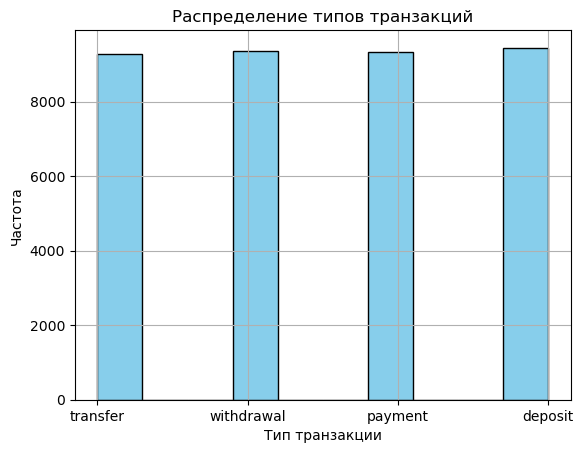

TransactionType
deposit       9450
withdrawal    9354
payment       9342
transfer      9271
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt

df['TransactionType'].hist(color='skyblue', edgecolor='black')
plt.title('Распределение типов транзакций')
plt.xlabel('Тип транзакции')
plt.ylabel('Частота')
plt.show()

print(df['TransactionType'].value_counts())

Типы транзакций (deposit, withdrawal, payment, transfer) представлены практически равномерно (от 9271 до 9450 записей). Это говорит о сбалансированности синтетических данных.

**Вывод:** дисбаланс классов отсутствует, что упрощает построение моделей классификации (например, для определения типа операции).

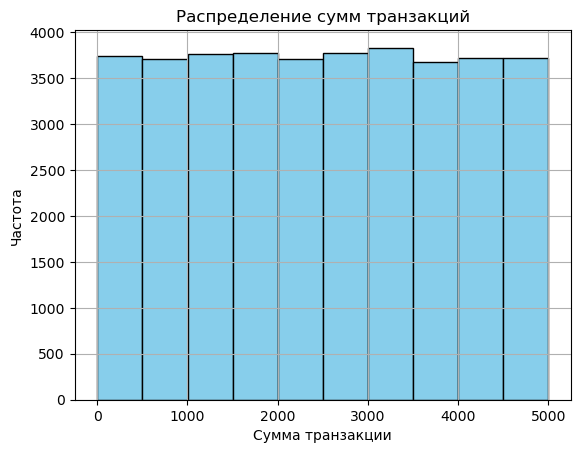

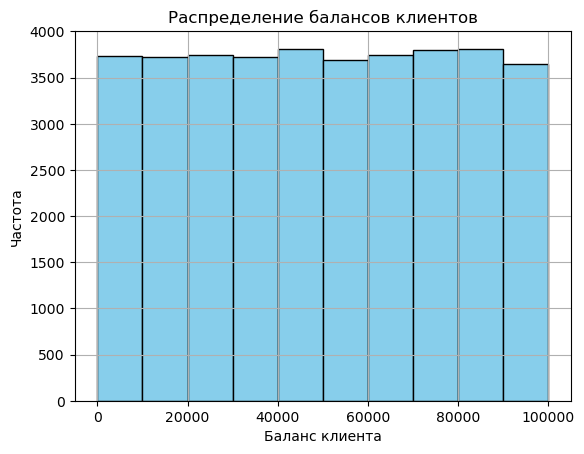

Баланс счета варьируется от 0.84 до 99997.21


In [14]:
df['TransactionAmount'].hist(color='skyblue', edgecolor='black')
plt.title('Распределение сумм транзакций')
plt.xlabel('Сумма транзакции')
plt.ylabel('Частота')
plt.show()

df['AccountBalance'].hist(color='skyblue', edgecolor='black')
plt.title('Распределение балансов клиентов')
plt.xlabel('Баланс клиента')
plt.ylabel('Частота')
plt.show()

print(f'Баланс счета варьируется от {df.AccountBalance.min()} до {df.AccountBalance.max()}')

***TransactionAmount*** распределены почти равномерно в диапазоне от 1 до 5000, среднее ~2498, медиана ~2502, стандартное отклонение ~1440. Это соответствует равномерному закону генерации данных.

**Вывод:** значительных выбросов нет (максимум близок к верхней границе 5000). Для обнаружения аномалий можно рассматривать суммы, близкие к границам диапазона, как потенциально подозрительные.

***AccountBalance*** варьируются от 0.84 до 99997, среднее ~50009, медиана ~49942. Распределение также близко к равномерному, без явных кластеров.

**Вывод:** все значения укладываются в заявленный диапазон [0, 100000], данные согласованы. Баланс сам по себе слабо информативен, но в сочетании с суммой операции может давать полезные признаки (например, остаток после крупного снятия).

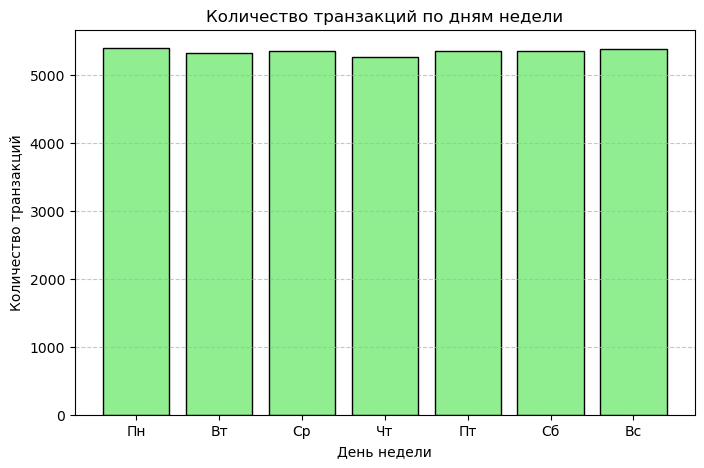

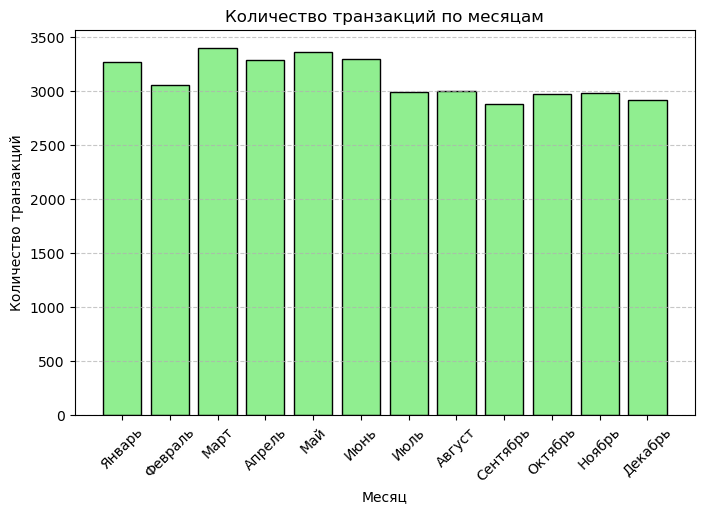

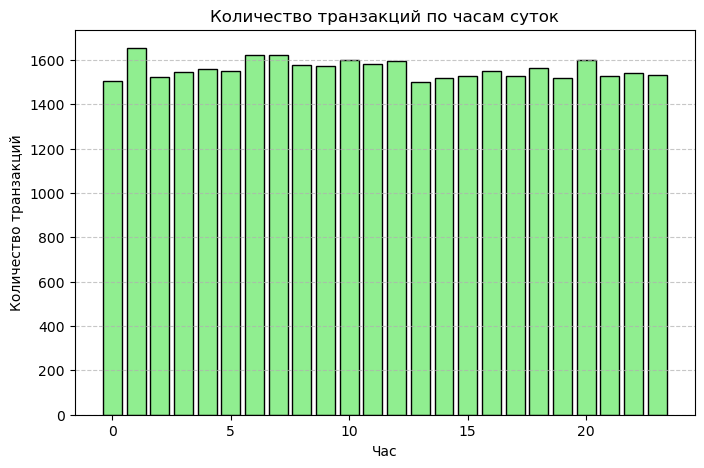

In [16]:
# Количество транзакций по дням недели

weekday_counts = df['day_of_week'].value_counts().sort_index()
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

plt.figure(figsize=(8,5))
plt.bar(days, weekday_counts.values, color='lightgreen', edgecolor='black')
plt.title('Количество транзакций по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество транзакций')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Количество транзакций по месяцам 

month_counts = df['month'].value_counts().sort_index()
months = ['Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь']

plt.figure(figsize=(8,5))
plt.bar(months, month_counts.values, color='lightgreen', edgecolor='black')
plt.title('Количество транзакций по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество транзакций')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Количество транзакций по часам 

hour_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(hour_counts.index, hour_counts.values, color='lightgreen', edgecolor='black')
plt.title('Количество транзакций по часам суток')
plt.xlabel('Час')
plt.ylabel('Количество транзакций')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

***Распределение по часам***
Наибольшее число транзакций приходится на 1 час ночи, наименьшее — на 13–14 часов дня. Это не соответствует реальным паттернам (обычно пик днём), что указывает на синтетическую природу данных.

**Вывод для конвейера:** при проектировании следует учитывать равномерность, но в реальных системах пики нагрузки будут смещены на дневное время. Необходимо предусмотреть возможность масштабирования под неравномерную нагрузку.

***Распределение по дням недели***
Количество транзакций практически одинаково во все дни недели (около 5300–5400). Отсутствие выраженных выходных/будних паттернов — ещё одно свидетельство синтетики.

**Вывод:** в реальных данных выходные обычно отличаются меньшей активностью, поэтому при переносе на реальные данные потребуется корректировка модели.

***Распределение по месяцам***
Наблюдается повышенное число транзакций в январе, марте–июне, пониженное — в сентябре и декабре. Однако следует учесть, что данные заканчиваются в середине 2024 года, поэтому декабрь представлен не полностью. Это артефакт, а не реальная сезонность.

**Вывод:** при анализе временных рядов нужно делать поправку на неполные периоды. В учебных целях можно игнорировать, но в выводах важно указать причину.

count    37416.000000
mean      7167.087743
std       7138.494699
min          0.000000
25%       2075.000000
50%       4967.500000
75%      10002.250000
max      91157.000000
Name: time_diff_sec, dtype: float64


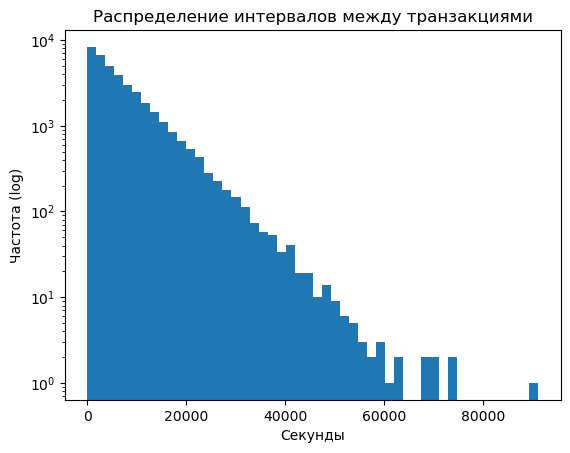

In [18]:
df_sorted = df.sort_values('Timestamp')
df_sorted['time_diff_sec'] = df_sorted['Timestamp'].diff().dt.total_seconds()
print(df_sorted['time_diff_sec'].describe())

plt.hist(df_sorted['time_diff_sec'].dropna(), bins=50, log=True)
plt.title('Распределение интервалов между транзакциями')
plt.xlabel('Секунды')
plt.ylabel('Частота (log)')
plt.show()

- Медианный интервал — 4967 секунд (~1 час 22 минуты), средний — 7167 секунд (~2 часа). Максимальный интервал достигает 25 часов.
- Минимальный интервал равен 0 секунд — возможны одновременные транзакции, что создаёт микро-пики.

**Вывод для конвейера:**

- Средняя интенсивность потока низкая (~1 транзакция в 1–2 часа), но требования к задержкам могут быть жёсткими для задач fraud detection.
- Необходима поддержка параллельной обработки на случай микро-пиков (несколько транзакций в одну секунду).
- Для агрегаций (скользящие средние, частота операций) можно использовать окна в несколько часов (например, 6 или 12 часов), так как интервалы велики.

C:\Users\lebed\AppData\Local\Temp\ipykernel_7796\4142747682.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='TransactionType', y='TransactionAmount', palette='Set2')


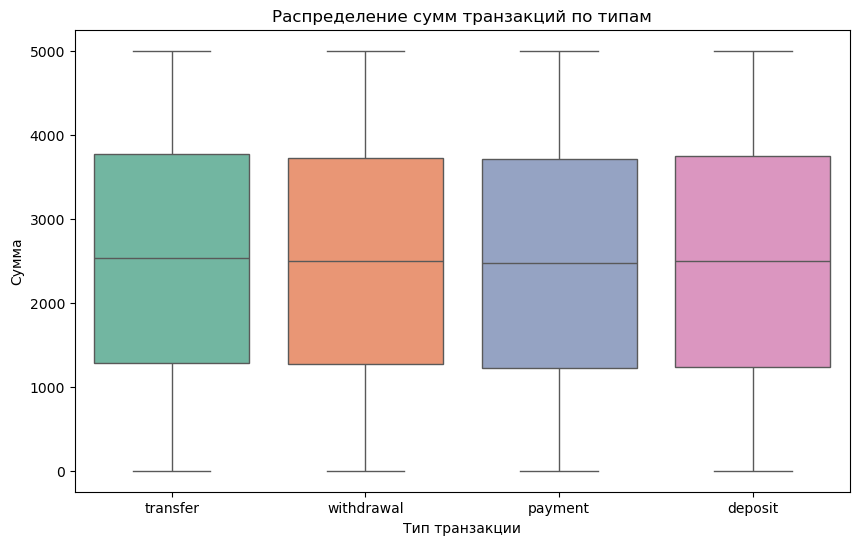

                        mean    median  count
TransactionType                              
deposit          2494.337742  2497.560   9450
payment          2477.960267  2475.195   9342
transfer         2521.773907  2529.650   9271
withdrawal       2497.365816  2496.410   9354


In [20]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='TransactionType', y='TransactionAmount', palette='Set2')
plt.title('Распределение сумм транзакций по типам')
plt.xlabel('Тип транзакции')
plt.ylabel('Сумма')
plt.show()

print(df.groupby('TransactionType')['TransactionAmount'].agg(['mean', 'median', 'count']))

Боксплоты и групповые статистики показывают практически идентичные распределения сумм для всех типов (средние около 2480–2520, медианы 2475–2530). Статистически значимых различий нет.

**Вывод:** в синтетических данных тип транзакции не влияет на сумму. В реальности это не так (например, переводы часто крупнее платежей). Поэтому для реального применения потребуются другие данные или дообучение.

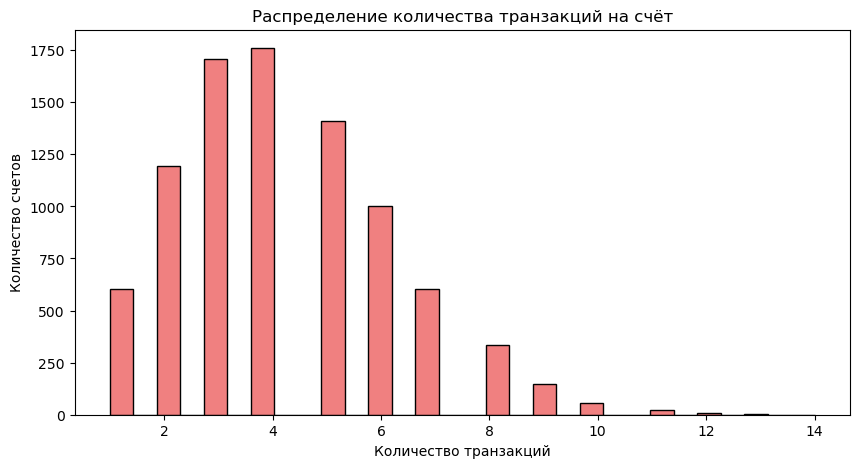

count    8856.000000
mean        4.225045
std         1.998319
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        14.000000
Name: transactions_count, dtype: float64
Топ-10 счетов по числу транзакций:
       AccountID  transactions_count
2253       3292                  14
1599       2633                  13
6889       7997                  13
2492       3535                  12
2668       3713                  12
3514       4578                  12
4166       5237                  12
4597       5670                  12
4991       6067                  12
6009       7108                  12


In [22]:
account_count = df.groupby('AccountID').size().reset_index(name='transactions_count')
plt.figure(figsize=(10,5))
plt.hist(account_count['transactions_count'], bins=30, color='lightcoral', edgecolor='black')
plt.title('Распределение количества транзакций на счёт')
plt.xlabel('Количество транзакций')
plt.ylabel('Количество счетов')
plt.show()

print(account_count['transactions_count'].describe())

top_accounts = account_count.nlargest(10, 'transactions_count')
print("Топ-10 счетов по числу транзакций:\n", top_accounts)

- Большинство счетов имеют от 1 до 5 транзакций, максимум — 14 транзакций за весь период. Распределение смещено влево (немного счетов с высокой активностью).
- Топ-10 активных счетов совершили 12–14 операций. Это можно использовать как baseline: счёт с резким увеличением частоты (например, >14 за короткое время) может считаться аномальным.

**Вывод:** признак «частота операций по счёту» потенциально полезен для обнаружения подозрительной активности.

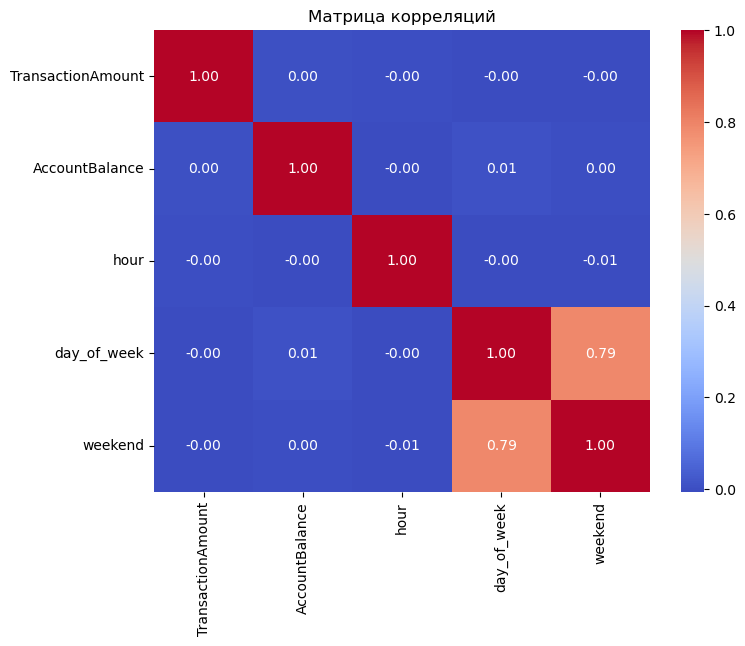

In [24]:
num_cols = ['TransactionAmount', 'AccountBalance', 'hour', 'day_of_week', 'weekend']

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляций')
plt.show()

Матрица корреляций числовых признаков показала близкие к нулю значения между всеми парами, кроме очевидной связи day_of_week и weekend (0.79).

**Вывод:** линейные зависимости между признаками отсутствуют. Для моделирования потребуются нелинейные методы или создание дополнительных признаков (например, изменение баланса, отношение суммы к среднему по счёту).

В ходе разведочного анализа данных установлено, что датасет является синтетическим, что проявляется в равномерных распределениях, отсутствии сезонности и слабых взаимосвязях между признаками. Однако он полностью соответствует описанию, не содержит пропусков и дубликатов, что делает его пригодным для учебных целей и отработки методологии построения конвейера данных в режиме, близком к реальному времени.

**Ключевые выводы для проектирования конвейера:**

*Низкая интенсивность потока:* медианный интервал между транзакциями ~1.5 часа. Это позволяет использовать относительно простую архитектуру, но требует учёта микро-пиков (интервалы ≤ 0 секунд).

*Допустимые задержки:* благодаря редким транзакциям можно допустить задержки в несколько секунд, однако для целей обнаружения мошенничества обработка должна быть максимально быстрой.

*Окна агрегации:* целесообразно использовать окна размером от 1 до 12 часов для расчёта скользящих статистик (средняя сумма, частота операций по счёту).

***Признаки для модели:***

- Сумма транзакции, тип, час, день недели.
- Частота операций по счёту (за последние N часов/дней).
- Отклонение суммы от среднего по счёту.
- Изменение баланса

*Ограничения:* данные не отражают реальных паттернов (пиковые нагрузки, сезонность), поэтому разработанный конвейер и модель потребуют адаптации при переходе на реальные данные.

***Заключение:*** EDA выполнен в полном объёме, все поставленные задачи решены. Полученные инсайты будут использованы при проектировании архитектуры конвейера и выборе методов обнаружения аномалий.